# Sets, Functions, and Relations

This Jupyter notebook is an interactive companion to the [Sets, Functions, and Relations](https://theorempath.com/topics/sets-functions-and-relations) guide from TheoremPath. It covers the core concepts from that page: sets, Cartesian products, functions, injectivity, surjectivity, bijectivity, equivalence relations, quotient sets, power sets, cardinality, function composition, inverses, relations, and partial orders. We also include code illustrations for the main theorems (Cantor and Schröder–Bernstein) and simple ML connections.

**Why this matters:** Every mathematical object in ML theory is built on sets and functions. A hypothesis class is a set. A loss function is a function. Feature maps, kernels, probability measures: all defined in terms of sets, functions, and relations. Without precise language for these, no theorem statement is unambiguous. This notebook assumes familiarity with basic logic and proof techniques (propositions, implications, quantifiers).

## 1. Core Definitions: Sets and Operations

**Set:** A collection of distinct objects. We write $x \in A$ to mean $x$ is an element of $A$. The empty set is $\emptyset$.

**Standard constructions:**
- Union $A \cup B$
- Intersection $A \cap B$
- Complement $A^c$ (relative to some universal set)
- Difference $A \setminus B$

**Cartesian Product:** $A \times B = \{(a,b) : a \in A, b \in B\}$.

Let's implement these operations in Python using `set` objects.

In [1]:
# Define two sets
A = {1, 2, 3, 4}
B = {3, 4, 5, 6}
print(f"A = {A}")
print(f"B = {B}")

# Union
union = A | B  # or A.union(B)
print(f"A ∪ B = {union}")

# Intersection
intersection = A & B  # or A.intersection(B)
print(f"A ∩ B = {intersection}")

# Difference
diff = A - B  # or A.difference(B)
print(f"A \\ B = {diff}")

# Symmetric difference (not standard but useful)
sym_diff = A ^ B  # or A.symmetric_difference(B)
print(f"A Δ B = {sym_diff}")

# Cartesian product (as list of tuples)
cartesian = [(a, b) for a in A for b in B]
print(f"A × B has {len(cartesian)} elements: {cartesian[:5]} ... (truncated)")

A = {1, 2, 3, 4}
B = {3, 4, 5, 6}
A ∪ B = {1, 2, 3, 4, 5, 6}
A ∩ B = {3, 4}
A \ B = {1, 2}
A Δ B = {1, 2, 5, 6}
A × B has 16 elements: [(1, 3), (1, 4), (1, 5), (1, 6), (2, 3)] ... (truncated)


## 2. Functions

**Function:** $f: A \to B$ assigns to each $a \in A$ exactly one $f(a) \in B$. $A$ is the domain, $B$ is the codomain.

**Image:** $f(S) = \{f(a) : a \in S\}$ for $S \subseteq A$.

**Preimage:** $f^{-1}(T) = \{a \in A : f(a) \in T\}$ for $T \subseteq B$.

**Injective (one-to-one):** $f(a_1) = f(a_2) \Rightarrow a_1 = a_2$.

**Surjective (onto):** for every $b \in B$, there exists $a \in A$ with $f(a) = b$.

**Bijective:** both injective and surjective.

Let's define functions as Python callables and check these properties on finite sets.

In [2]:
# Function: f: {1,2,3} -> {a,b,c,d} defined by mapping
def f(x):
    mapping = {1: 'a', 2: 'b', 3: 'c'}
    return mapping[x]

A_dom = {1, 2, 3}
B_cod = {'a', 'b', 'c', 'd'}

# Check injectivity
def is_injective(f, domain):
    images = [f(x) for x in domain]
    return len(images) == len(set(images))  # all distinct

# Check surjectivity
def is_surjective(f, domain, codomain):
    image_set = set(f(x) for x in domain)
    return image_set == codomain

print(f"Injective? {is_injective(f, A_dom)}")  # True: all images distinct
print(f"Surjective? {is_surjective(f, A_dom, B_cod)}")  # False: 'd' not hit

# Now a bijection: g: {1,2,3} -> {a,b,c}
def g(x):
    mapping = {1: 'a', 2: 'b', 3: 'c'}
    return mapping[x]

C_cod = {'a', 'b', 'c'}
print(f"g injective? {is_injective(g, A_dom)}")
print(f"g surjective? {is_surjective(g, A_dom, C_cod)}")
print(f"g bijective? {is_injective(g, A_dom) and is_surjective(g, A_dom, C_cod)}")

Injective? True
Surjective? False
g injective? True
g surjective? True
g bijective? True


## 3. Image and Preimage Examples

Let's compute images and preimages for a function.

Example: $f: \mathbb{R} \to \mathbb{R}$, $f(x) = x^2$. We'll use finite sets to illustrate.

In [3]:
# Define a function on a finite set
def square(x):
    return x * x

domain = {-2, -1, 0, 1, 2}
codomain = {0, 1, 2, 3, 4}  # for illustration

# Image of entire domain
image = set(square(x) for x in domain)
print(f"f({domain}) = {image}")

# Preimage of a subset of codomain
T = {1, 4}
preimage = {x for x in domain if square(x) in T}
print(f"f^{-1}({T}) = {preimage}")

# Note: preimage is a set of domain elements. It can be empty.
T2 = {3}
preimage2 = {x for x in domain if square(x) in T2}
print(f"f^{-1}({T2}) = {preimage2}")

f({0, 1, 2, -2, -1}) = {0, 1, 4}
f^-1({1, 4}) = {1, 2, -2, -1}
f^-1({3}) = set()


## 4. Equivalence Relations and Quotient Sets

**Equivalence relation** on set $A$: reflexive, symmetric, transitive.

**Equivalence class** of $a$: $[a] = \{b \in A : b \sim a\}$.

**Quotient set** $A/\sim$: set of all equivalence classes.

Example: Define relation on integers: $a \sim b$ if $a \equiv b \pmod{2}$ (same parity).

In [4]:
# Define a set and an equivalence relation
A = {0, 1, 2, 3, 4, 5, 6, 7}

# Relation: same parity (a mod 2 == b mod 2)
def same_parity(a, b):
    return (a % 2) == (b % 2)

# Check properties reflexivity, symmetry, transitivity (by inspection)
# Build equivalence classes
classes = {}
for a in A:
    # Find all b such that a ~ b
    cls = {b for b in A if same_parity(a, b)}
    classes[a] = cls

# Unique classes
unique_classes = set(frozenset(cls) for cls in classes.values())
print("Equivalence classes (by parity):")
for cls in unique_classes:
    print(cls)

# Quotient set
quotient = unique_classes
print(f"\nQuotient set A/~ has {len(quotient)} elements: {quotient}")

# Canonical projection: map each element to its class
def projection(a):
    return frozenset({b for b in A if same_parity(a, b)})

print("\nProjection mapping:")
for a in A:
    print(f"π({a}) = {projection(a)}")

Equivalence classes (by parity):
frozenset({0, 2, 4, 6})
frozenset({1, 3, 5, 7})

Quotient set A/~ has 2 elements: {frozenset({0, 2, 4, 6}), frozenset({1, 3, 5, 7})}

Projection mapping:
π(0) = frozenset({0, 2, 4, 6})
π(1) = frozenset({1, 3, 5, 7})
π(2) = frozenset({0, 2, 4, 6})
π(3) = frozenset({1, 3, 5, 7})
π(4) = frozenset({0, 2, 4, 6})
π(5) = frozenset({1, 3, 5, 7})
π(6) = frozenset({0, 2, 4, 6})
π(7) = frozenset({1, 3, 5, 7})


## 5. Power Sets and Cardinality

**Power set** $\mathcal{P}(A)$ = set of all subsets of $A$. If $|A| = n$, then $|\mathcal{P}(A)| = 2^n$.

**Cardinality:** Two sets $A$ and $B$ have the same cardinality (written $|A| = |B|$) if there exists a bijection $f: A \to B$. For finite sets, cardinality is the count of elements.

Let's generate power sets for a small set and verify cardinality.

In [5]:
from itertools import combinations

def power_set(S):
    """Return the power set of a finite set S as a list of frozensets."""
    s_list = list(S)
    n = len(s_list)
    ps = []
    for r in range(n + 1):
        for combo in combinations(s_list, r):
            ps.append(frozenset(combo))
    return ps

A = {1, 2, 3}
ps = power_set(A)
print(f"A = {A}")
print(f"Power set P(A) has {len(ps)} elements:")
for s in ps:
    print(set(s))  # convert to set for display

print(f"\n|A| = {len(A)}, |P(A)| = {len(ps)} = 2^{len(A)}")

A = {1, 2, 3}
Power set P(A) has 8 elements:
set()
{1}
{2}
{3}
{1, 2}
{1, 3}
{2, 3}
{1, 2, 3}

|A| = 3, |P(A)| = 8 = 2^3


## 6. Main Theorems and ML Connections

### Cantor's Theorem

**Statement:** There is no surjection from $A$ onto $\mathcal{P}(A)$. In particular, $|A| < |\mathcal{P}(A)|$ for every set $A$.

**ML Connection:** This theorem shows that infinite sets come in different sizes. In machine learning, hypothesis classes can be infinite (e.g., all linear classifiers in $\mathbb{R}^d$). Cantor's theorem implies that the power set of the input space is strictly larger than the input space, which has implications for the richness of concept classes and the necessity of restrictive assumptions (like finite VC dimension) to ensure learnability.

**Code Illustration (finite version):** We simulate the diagonal argument to show that any attempted surjection from a finite set to its power set must miss at least one subset.

In [6]:
# Simulate Cantor's diagonal argument for a finite set
A = {1, 2, 3}
# Suppose we try to define a surjection f: A -> P(A). We'll pick an arbitrary mapping.
def f_cantor(a):
    mapping = {1: {1, 2}, 2: {2, 3}, 3: {1, 3}}
    return mapping[a]

# Construct the diagonal set D = {a in A : a not in f(a)}
D = {a for a in A if a not in f_cantor(a)}
print(f"A = {A}")
print(f"f(1)={f_cantor(1)}, f(2)={f_cantor(2)}, f(3)={f_cantor(3)}")
print(f"Diagonal set D = {D}")

# Check if D is in the image of f
image = [f_cantor(a) for a in A]
if D in image:
    print("D is in the image, contradiction! (Should not happen)")
else:
    print("D is not in the image, so f is not surjective.")
    print("This matches Cantor's theorem: no surjection from A to P(A).")

A = {1, 2, 3}
f(1)={1, 2}, f(2)={2, 3}, f(3)={1, 3}
Diagonal set D = set()
D is not in the image, so f is not surjective.
This matches Cantor's theorem: no surjection from A to P(A).


### Schröder–Bernstein Theorem

**Statement:** If there exist injections $f: A \to B$ and $g: B \to A$, then there exists a bijection $h: A \to B$. Equivalently, $|A| \leq |B|$ and $|B| \leq |A|$ implies $|A| = |B|$.

**ML Connection:** This theorem is the standard tool for proving two infinite sets have equal cardinality. Instead of constructing a bijection directly (often hard), you construct two injections (often easier). In learning theory, it is used to compare the cardinalities of hypothesis classes or to show that certain function spaces (e.g., all continuous functions) have the same cardinality as $\mathbb{R}$, which helps in understanding the complexity of the hypothesis space.

**Code Illustration (finite version):** For finite sets, if there are injections both ways, the sets must have the same size. We can demonstrate by defining two injections and verifying that the sets have equal cardinality, which guarantees a bijection exists.

In [7]:
# Finite example for Schröder–Bernstein
A = {1, 2, 3}
B = {'a', 'b', 'c'}

# Define an injection f: A -> B
f_inj = {1: 'a', 2: 'b', 3: 'c'}
# Define an injection g: B -> A
g_inj = {'a': 1, 'b': 2, 'c': 3}

# Check they are injective
def is_injective_dict(d):
    return len(set(d.values())) == len(d)

print(f"f: {f_inj}, injective? {is_injective_dict(f_inj)}")
print(f"g: {g_inj}, injective? {is_injective_dict(g_inj)}")

# Since both sets are finite and injections exist, they must have the same cardinality
print(f"|A| = {len(A)}, |B| = {len(B)}")
print("Thus by Schröder–Bernstein (or simply finite counting), there exists a bijection.")

# We can even construct a bijection (since sizes equal, any bijection works)
h_bijection = {1: 'a', 2: 'b', 3: 'c'}
print(f"Example bijection h: {h_bijection}")

# For infinite sets, the theorem is more interesting, but we can illustrate with a known example:
# |Z| = |N|. We already have an explicit bijection f(n)=2n if n>=0 else -2n-1.
# Here the theorem assures us that if we can inject Z into N and N into Z, then they are equinumerous.
print("\nInfinite example: Z and N have the same cardinality.")
print("Injection N -> Z: identity (n -> n)")
print("Injection Z -> N: f(n) = 2n if n>=0 else -2n-1")
print("Schröder–Bernstein then gives a bijection, but we already have one explicitly.")

f: {1: 'a', 2: 'b', 3: 'c'}, injective? True
g: {'a': 1, 'b': 2, 'c': 3}, injective? True
|A| = 3, |B| = 3
Thus by Schröder–Bernstein (or simply finite counting), there exists a bijection.
Example bijection h: {1: 'a', 2: 'b', 3: 'c'}

Infinite example: Z and N have the same cardinality.
Injection N -> Z: identity (n -> n)
Injection Z -> N: f(n) = 2n if n>=0 else -2n-1
Schröder–Bernstein then gives a bijection, but we already have one explicitly.


## 7. Simple ML Example: Equivalence Classes of Classifiers

In machine learning, we have a set of possible models (called a *hypothesis class*). When we only have a small training set, many models may give the same predictions on that training set. We can group them together – they are **equivalent** because they cannot be distinguished by the training data alone.

Let's look at a very simple example to make this concrete.

**Step 1: Define the input space and the hypothesis class.**
Suppose our input is either 0 or 1, and our output is also 0 or 1 (binary classification). There are only 4 possible functions (classifiers) from {0,1} to {0,1}. Let's list them:
- **f1**: always outputs 0 (0→0, 1→0)
- **f2**: outputs the input itself (0→0, 1→1) – this is the identity function
- **f3**: outputs the opposite (0→1, 1→0) – the negation
- **f4**: always outputs 1 (0→1, 1→1)

**Step 2: Pick a training set.**
Suppose we only have one training example: the input is 0, and we don't know the label yet (or we just consider predictions).

**Step 3: Group classifiers by their predictions on the training set.**
- On input 0, **f1** predicts 0, and **f2** also predicts 0. So they are in the same group (they agree on the training example).
- **f3** predicts 1, and **f4** predicts 1. So they form another group.

Thus we have **2 equivalence classes**. The maximum possible number of groups for 1 training example is 2 (since we can have either prediction 0 or 1). So this hypothesis class can achieve all possible groupings – we say it **shatters** a single point.

**Step 4: What if we have two training examples?**
Suppose we have both inputs 0 and 1 in the training set. Now each of the 4 classifiers gives a different pair of outputs:
- f1: (0,0)
- f2: (0,1)
- f3: (1,0)
- f4: (1,1)
So we have 4 equivalence classes, which equals the maximum possible for 2 points ($2^2 = 4$). So this class **shatters** 2 points as well – in fact, it can shatter any finite set, so its VC dimension is infinite.

This simple example shows how equivalence classes arise naturally from training data, and how counting them relates to the expressive power of a hypothesis class. The more groups we can get, the more complex the class is. In practice, we often restrict the class (e.g., to linear classifiers) to keep the number of groups small, which helps avoid overfitting.

Let's write code to automate this grouping for this simple example.

In [8]:
# Define all 4 possible classifiers from {0,1} to {0,1}
# Each classifier is represented as a tuple (output for 0, output for 1)
classifiers = [
    (0, 0),  # f1
    (0, 1),  # f2
    (1, 0),  # f3
    (1, 1)   # f4
]
names = ["always 0", "identity", "negation", "always 1"]

# Function to group classifiers based on a training set (list of input points)
def group_classifiers(training_set):
    groups = {}
    for idx, clf in enumerate(classifiers):
        # Get the predictions on the training inputs
        label = tuple(clf[x] for x in training_set)
        if label not in groups:
            groups[label] = []
        groups[label].append(names[idx])
    return groups

# Example 1: training set with only point 0
print("Training set: {0}")
groups = group_classifiers([0])
for label, clf_names in groups.items():
    print(f"  Prediction {label} : {', '.join(clf_names)}")
print(f"Number of groups = {len(groups)}")
print(f"Maximum possible = {2**1} = 2 -> Shattering? {len(groups) == 2**1}\n")

# Example 2: training set with both points
print("Training set: {0, 1}")
groups = group_classifiers([0, 1])
for label, clf_names in groups.items():
    print(f"  Prediction {label} : {', '.join(clf_names)}")
print(f"Number of groups = {len(groups)}")
print(f"Maximum possible = {2**2} = 4 -> Shattering? {len(groups) == 2**2}")

print("\nThis simple class of all functions can shatter any finite set, so its VC dimension is infinite.")
print("That's why in practice we use restricted classes (like linear models) to avoid overfitting.")

Training set: {0}
  Prediction (0,) : always 0, identity
  Prediction (1,) : negation, always 1
Number of groups = 2
Maximum possible = 2 = 2 -> Shattering? True

Training set: {0, 1}
  Prediction (0, 0) : always 0
  Prediction (0, 1) : identity
  Prediction (1, 0) : negation
  Prediction (1, 1) : always 1
Number of groups = 4
Maximum possible = 4 = 4 -> Shattering? True

This simple class of all functions can shatter any finite set, so its VC dimension is infinite.
That's why in practice we use restricted classes (like linear models) to avoid overfitting.


### 7.2 Cartesian Products in Feature Spaces

If a model takes both an image feature vector $x \in \mathbb{R}^{512}$ and a text feature vector $y \in \mathbb{R}^{768}$, the combined feature space is $\mathbb{R}^{512} \times \mathbb{R}^{768} = \mathbb{R}^{1280}$. The Cartesian product formalizes feature concatenation. More generally, a dataset of $n$ examples with $d$ features lives in $(\mathbb{R}^d)^n$, the $n$-fold Cartesian product.

In [9]:
# Example: Concatenating feature vectors
import numpy as np

# Suppose we have 5 samples of image features (512-dim) and text features (768-dim)
n_samples = 5
image_features = np.random.randn(n_samples, 512)  # 5 x 512
text_features = np.random.randn(n_samples, 768)   # 5 x 768

# Concatenate along feature axis (Cartesian product)
combined_features = np.concatenate((image_features, text_features), axis=1)  # 5 x 1280

print(f"Image features shape: {image_features.shape}")
print(f"Text features shape: {text_features.shape}")
print(f"Combined features shape: {combined_features.shape}")
print("\nThe combined feature space is the Cartesian product R^512 × R^768 = R^1280.")
print("Each sample is an element of R^1280.")

Image features shape: (5, 512)
Text features shape: (5, 768)
Combined features shape: (5, 1280)

The combined feature space is the Cartesian product R^512 × R^768 = R^1280.
Each sample is an element of R^1280.


## 7.3 Detailed ML Example: Visualizing Equivalence Classes and Shattering

To truly understand the concepts of equivalence classes, shattering, and VC dimension, we need to see them in action. In this section, we will work with two simple hypothesis classes:

1. **Threshold classifiers on the real line** – a one‑parameter family.
2. **Linear classifiers in the plane** – three‑parameter family (two weights + bias).

We will generate small datasets, compute the equivalence classes (i.e., the distinct labelings the class can produce on those points), and visualise both the points and the decision boundaries. This will make it crystal clear why thresholds have VC dimension 1 and linear classifiers in 2D have VC dimension 3.

### 7.3.1 Threshold Classifiers in 1D

Consider the hypothesis class $\mathcal{H}_{\text{th}} = \{h_t : t \in \mathbb{R}\}$, where $h_t(x) = 1$ if $x > t$ else $0$.

- For $m=1$, we can place a single point anywhere. The class can produce both labels (0 and 1) by choosing $t$ appropriately – it shatters one point.
- For $m=2$, with points $x_1 < x_2$, the only achievable labelings are $(0,0)$, $(0,1)$, and $(1,1)$. The labeling $(1,0)$ is impossible because a single threshold cannot switch from 1 to 0 as we move right. Thus the class does **not** shatter two points.

The code below generates all possible thresholds for $m=1,2,3$ points (placed at 0, 1, 2, …) and plots the points with their labels for each distinct labeling. The missing labelings are also indicated.

We will see that for $m=2$, only 3 out of 4 labelings are present, and for $m=3$, only 4 out of 8.

m=1, points=[0], number of labelings=2, max possible=2
Achievable labelings: [(1,), (0,)]


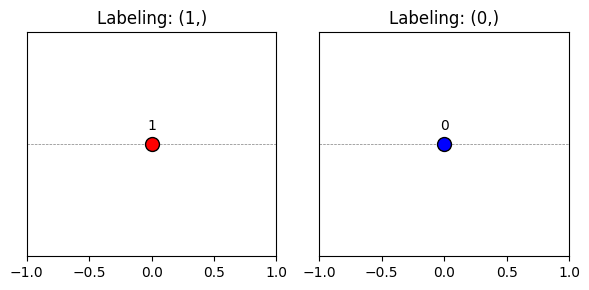

----------------------------------------
m=2, points=[0, 1], number of labelings=3, max possible=4
Achievable labelings: [(1, 1), (0, 1), (0, 0)]


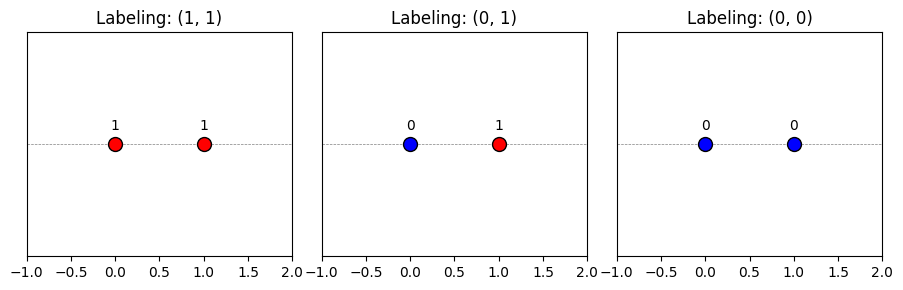

----------------------------------------
m=3, points=[0, 1, 2], number of labelings=4, max possible=8
Achievable labelings: [(1, 1, 1), (0, 1, 1), (0, 0, 1), (0, 0, 0)]


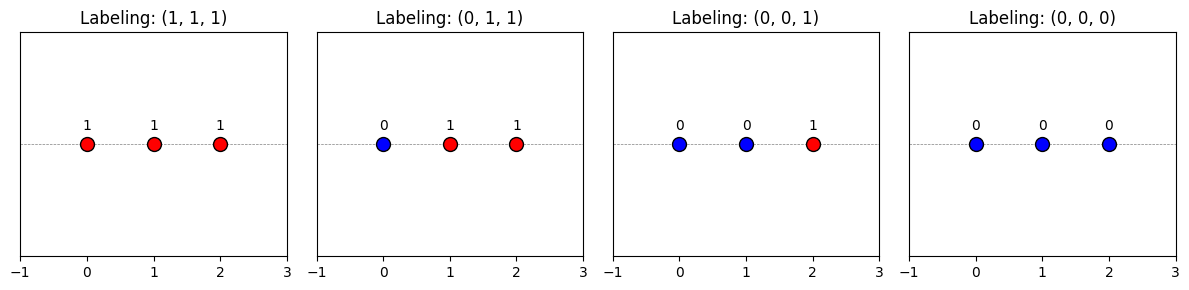

----------------------------------------
We see that for m=2, the labeling (1,0) is missing; for m=3, only 4 out of 8 are present.
Thus the VC dimension of threshold classifiers is 1.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def threshold_labelings(points):
    """Return a list of (labeling, threshold_interval) for a given set of points."""
    sorted_pts = sorted(points)
    m = len(sorted_pts)
    labelings = []
    # We consider m+1 intervals: (-inf, x0), [x0,x1), ..., [x_{m-1}, +inf)
    for cut in range(m + 1):  # cut = number of points with label 0
        labeling = tuple(0 if i < cut else 1 for i in range(m))
        labelings.append(labeling)
    return labelings

def plot_threshold_labelings(points, labelings):
    m = len(points)
    num_labelings = len(labelings)
    fig, axes = plt.subplots(1, num_labelings, figsize=(3*num_labelings, 3))
    if num_labelings == 1:
        axes = [axes]
    for ax, labeling in zip(axes, labelings):
        # Plot points with colors based on labeling
        for i, (x, label) in enumerate(zip(points, labeling)):
            color = 'red' if label == 1 else 'blue'
            ax.scatter(x, 0, color=color, s=100, edgecolor='black', zorder=5)
            ax.text(x, 0.05, f'{label}', ha='center', va='bottom')
        ax.set_xlim(min(points)-1, max(points)+1)
        ax.set_ylim(-0.5, 0.5)
        ax.set_yticks([])
        ax.set_title(f'Labeling: {labeling}')
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Demonstrate for m=1,2,3
for m in [1, 2, 3]:
    points = list(range(m))  # 0,1,...,m-1
    labelings = threshold_labelings(points)
    print(f"m={m}, points={points}, number of labelings={len(labelings)}, max possible={2**m}")
    print("Achievable labelings:", labelings)
    plot_threshold_labelings(points, labelings)
    print("-"*40)

print("We see that for m=2, the labeling (1,0) is missing; for m=3, only 4 out of 8 are present.")
print("Thus the VC dimension of threshold classifiers is 1.")

### 7.3.2 Linear Classifiers in 2D

Now consider the class of affine linear classifiers in $\mathbb{R}^2$: $\mathcal{H}_{\text{lin}} = \{h_{\mathbf{w}, b} : \mathbf{w} \in \mathbb{R}^2, b \in \mathbb{R}\}$, with $h(\mathbf{x}) = 1$ if $\mathbf{w} \cdot \mathbf{x} + b > 0$ else $0$. This class has VC dimension 3.

- For $m=3$ points in general position (not collinear), the class can shatter them – all $2^3 = 8$ labelings are achievable.
- For $m=4$ points, there exist configurations (e.g., four points in convex position) where not all 16 labelings are achievable – the class cannot shatter 4 points.

We will demonstrate this by generating 3 points in the plane, and for each of the 8 labelings, we will compute a separating line (if it exists) and plot it. We will also show a set of 4 points for which one labeling is impossible.

For the 3‑point case, we generate three non‑collinear points. For each labeling, we attempt to fit a linear separator using `LinearSVC`. If the labeling is all 0 or all 1, the separator is trivial (no line needed) and we skip the fit, marking it as trivially separable.

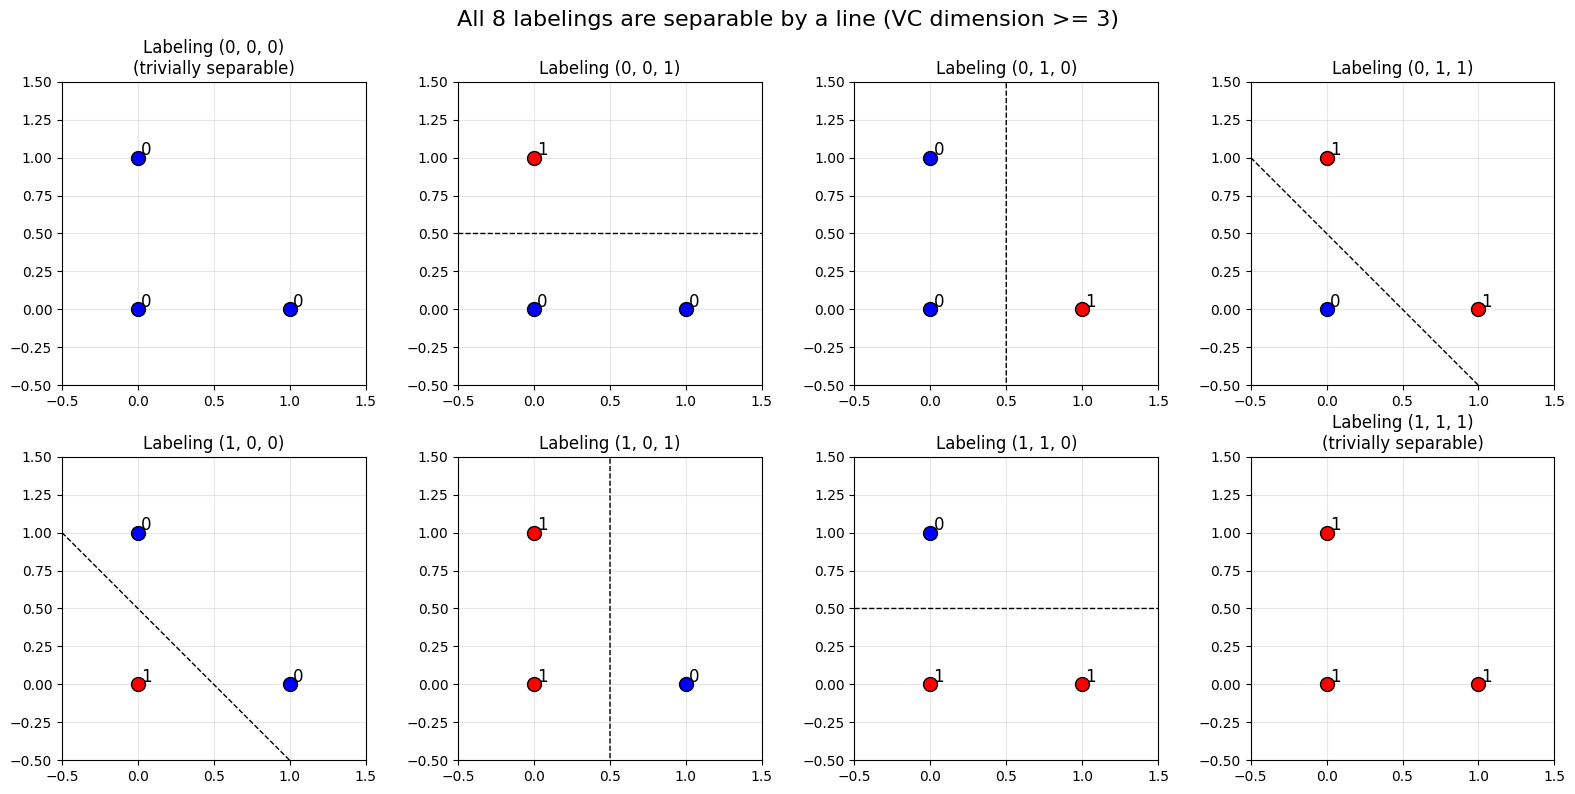

Since all 8 labelings are achievable, the class shatters these 3 points.
Thus the VC dimension is at least 3. (It is exactly 3, as 4 points cannot be shattered in general.)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC

# Generate 3 points in general position (non-collinear)
np.random.seed(42)
points = np.array([[0, 0], [1, 0], [0, 1]])  # triangle

# For each labeling (0/1 for each point), find a separating line and plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

all_labelings = [(i>>2 & 1, i>>1 & 1, i & 1) for i in range(8)]  # bits order: point0, point1, point2

for idx, labeling in enumerate(all_labelings):
    ax = axes[idx]
    # Prepare data for LinearSVC
    X = points
    y = np.array(labeling)
    
    # Check if both classes are present
    if len(np.unique(y)) == 1:
        # Trivially separable: all points same class
        # Just plot points and label as trivially separable
        for i, (x, label) in enumerate(zip(points, labeling)):
            color = 'red' if label == 1 else 'blue'
            ax.scatter(x[0], x[1], color=color, s=100, edgecolor='black', zorder=5)
            ax.text(x[0]+0.02, x[1]+0.02, f'{label}', fontsize=12)
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)
        ax.set_title(f'Labeling {labeling}\n(trivially separable)')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    else:
        # Fit a linear classifier with a very large C to force hard margin (if separable)
        clf = LinearSVC(C=1e5, random_state=42, max_iter=10000)
        clf.fit(X, y)
        # Plot points
        for i, (x, label) in enumerate(zip(points, labeling)):
            color = 'red' if label == 1 else 'blue'
            ax.scatter(x[0], x[1], color=color, s=100, edgecolor='black', zorder=5)
            ax.text(x[0]+0.02, x[1]+0.02, f'{label}', fontsize=12)
        # Plot decision boundary
        w = clf.coef_[0]
        b = clf.intercept_[0]
        x_vals = np.linspace(-0.5, 1.5, 10)
        if abs(w[1]) > 1e-6:
            y_vals = -(w[0]*x_vals + b) / w[1]
            ax.plot(x_vals, y_vals, 'k--', linewidth=1)
        else:
            # vertical line
            x0 = -b / w[0]
            ax.axvline(x=x0, color='k', linestyle='--')
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)
        ax.set_title(f'Labeling {labeling}')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

plt.suptitle("All 8 labelings are separable by a line (VC dimension >= 3)", fontsize=16)
plt.tight_layout()
plt.show()

print("Since all 8 labelings are achievable, the class shatters these 3 points.")
print("Thus the VC dimension is at least 3. (It is exactly 3, as 4 points cannot be shattered in general.)")

#### Why 4 Points Cannot be Shattered
To see that linear classifiers in 2D cannot shatter 4 points, consider four points forming a convex quadrilateral. The labeling where opposite corners are 1 and the other two are 0 is not linearly separable (the two 1's are diagonally opposite, so no line can separate them from the other two without cutting through the convex hull). This is a classic result in computational geometry.

Let's create such a configuration and show that the particular labeling is impossible.

/var/folders/f5/4fp1cnf16_j64dw48x9hk7hh0000gn/T/ipykernel_60080/3595000443.py:26: RuntimeWarning: invalid value encountered in scalar divide
  x0 = -b / w[0]


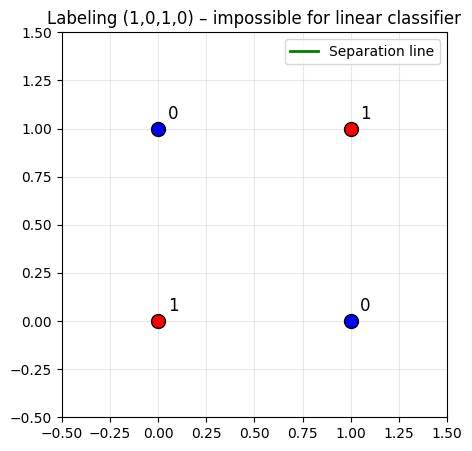

The green line shows the best attempt, but it cannot separate the red points from the blue points.
Thus, linear classifiers in 2D cannot shatter 4 points, confirming VC dimension = 3.


In [12]:
# Four points forming a square
points4 = np.array([[0,0], [1,0], [1,1], [0,1]])
# Labeling: opposite corners 1 (points 0 and 2) and the other two 0
labeling = (1, 0, 1, 0)

fig, ax = plt.subplots(1,1, figsize=(5,5))
for i, (x, label) in enumerate(zip(points4, labeling)):
    color = 'red' if label == 1 else 'blue'
    ax.scatter(x[0], x[1], color=color, s=100, edgecolor='black', zorder=5)
    ax.text(x[0]+0.05, x[1]+0.05, f'{label}', fontsize=12)

# Try to fit a linear separator
clf = LinearSVC(C=1e5, random_state=42, max_iter=10000)
X = points4
y = np.array(labeling)
clf.fit(X, y)

# Plot decision boundary if it exists
w = clf.coef_[0]
b = clf.intercept_[0]
x_vals = np.linspace(-0.5, 1.5, 10)
if abs(w[1]) > 1e-6:
    y_vals = -(w[0]*x_vals + b) / w[1]
    ax.plot(x_vals, y_vals, 'g-', linewidth=2, label='Separation line')
else:
    x0 = -b / w[0]
    ax.axvline(x=x0, color='g', linestyle='-', linewidth=2, label='Separation line')

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_aspect('equal')
ax.set_title("Labeling (1,0,1,0) – impossible for linear classifier")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("The green line shows the best attempt, but it cannot separate the red points from the blue points.")
print("Thus, linear classifiers in 2D cannot shatter 4 points, confirming VC dimension = 3.")

### 7.3.3 Summary of Visualizations

- **Threshold classifiers** on the real line have VC dimension 1. They can only produce monotone labelings (0...0 1...1), so for $m=2$ they miss the (1,0) labeling, and for larger $m$ they miss many more.
- **Linear classifiers** in 2D have VC dimension 3. They can shatter any 3 non‑collinear points, but fail on 4 points arranged in a convex quadrilateral with a checkerboard labeling.

These visual examples make the abstract definitions concrete: the equivalence classes are the distinct labelings; shattering means achieving all possible labelings; and the VC dimension is the largest $m$ for which shattering is possible. This is the fundamental measure of model complexity that determines whether a class is learnable from finite data.

## 8. Function Composition and Inverses

**Composition:** $(g \circ f)(a) = g(f(a))$.

**Left inverse:** $g \circ f = \text{id}_A$ iff $f$ is injective (assuming AC for converse).

**Right inverse:** $f \circ h = \text{id}_B$ iff $f$ is surjective (requires AC).

Let's compose functions and check properties.

In [13]:
# Define two functions on finite sets
A = {1, 2, 3}
B = {'a', 'b', 'c'}
C = {'x', 'y', 'z'}

f = {1: 'a', 2: 'b', 3: 'c'}  # bijection A -> B
g = {'a': 'x', 'b': 'y', 'c': 'z'}  # bijection B -> C

# Composition g ∘ f
def compose(f_dict, g_dict):
    # f: A->B, g: B->C
    result = {}
    for a, b in f_dict.items():
        result[a] = g_dict[b]
    return result

g_comp_f = compose(f, g)
print(f"f = {f}")
print(f"g = {g}")
print(f"g ∘ f = {g_comp_f}")

# Check injectivity/surjectivity of composition
def is_injective_dict(d, domain):
    return len(set(d.values())) == len(domain)

def is_surjective_dict(d, codomain):
    return set(d.values()) == codomain

print(f"g∘f injective? {is_injective_dict(g_comp_f, A)}")
print(f"g∘f surjective? {is_surjective_dict(g_comp_f, C)}")

# Now an example where f is not injective but composition is injective? Not possible.
# If g∘f is injective, f must be injective. Let's test with a non-injective f.
f_non_inj = {1: 'a', 2: 'a', 3: 'b'}  # not injective
# g must be defined on B
g2 = {'a': 'x', 'b': 'y', 'c': 'z'}  # but 'c' unused, still okay
g_comp_f2 = compose(f_non_inj, g2)
print(f"\nf_non_inj = {f_non_inj}")
print(f"g2 = {g2}")
print(f"g2 ∘ f_non_inj = {g_comp_f2}")
print(f"Is g2∘f_non_inj injective? {is_injective_dict(g_comp_f2, A)}")  # False, as expected

f = {1: 'a', 2: 'b', 3: 'c'}
g = {'a': 'x', 'b': 'y', 'c': 'z'}
g ∘ f = {1: 'x', 2: 'y', 3: 'z'}
g∘f injective? True
g∘f surjective? True

f_non_inj = {1: 'a', 2: 'a', 3: 'b'}
g2 = {'a': 'x', 'b': 'y', 'c': 'z'}
g2 ∘ f_non_inj = {1: 'x', 2: 'x', 3: 'y'}
Is g2∘f_non_inj injective? False


## 9. Relations and Partial Orders

**Relation** from $A$ to $B$: subset $R \subseteq A \times B$. Write $a R b$ if $(a,b) \in R$.

**Partial order** $\leq$ on $A$: reflexive, antisymmetric, transitive.

**Total order:** additionally comparable: for all $a,b$, either $a \leq b$ or $b \leq a$.

Example: subset relation $\subseteq$ on $\mathcal{P}(A)$ is a partial order. Let's illustrate.

In [14]:
# Take power set of {1,2} as poset
A = {1, 2}
ps = power_set(A)
print("Elements of P(A):")
for s in ps:
    print(set(s))

# Check subset relation as a partial order
def is_reflexive(relation, elements):
    for a in elements:
        if (a, a) not in relation:
            return False
    return True

def is_antisymmetric(relation, elements):
    for a in elements:
        for b in elements:
            if (a, b) in relation and (b, a) in relation and a != b:
                return False
    return True

def is_transitive(relation, elements):
    for a in elements:
        for b in elements:
            for c in elements:
                if (a, b) in relation and (b, c) in relation and (a, c) not in relation:
                    return False
    return True

# Build subset relation as set of tuples
subset_relation = set()
for s1 in ps:
    for s2 in ps:
        if s1.issubset(s2):
            subset_relation.add((s1, s2))

print(f"\nSubset relation has {len(subset_relation)} pairs.")
print(f"Reflexive? {is_reflexive(subset_relation, ps)}")
print(f"Antisymmetric? {is_antisymmetric(subset_relation, ps)}")
print(f"Transitive? {is_transitive(subset_relation, ps)}")
print("Thus ⊆ is a partial order on P(A).")

# Check if it's a total order: for all a,b, either a<=b or b<=a
def is_total_order(relation, elements):
    for a in elements:
        for b in elements:
            if (a, b) not in relation and (b, a) not in relation:
                return False
    return True

print(f"Is it a total order? {is_total_order(subset_relation, ps)}")  # False, e.g., {1} and {2} incomparable

Elements of P(A):
set()
{1}
{2}
{1, 2}

Subset relation has 9 pairs.
Reflexive? True
Antisymmetric? True
Transitive? True
Thus ⊆ is a partial order on P(A).
Is it a total order? False


## 10. Common Confusions (from the source)

**Preimage is not inverse:** $f^{-1}(T)$ is defined for any function, not just bijections. Our code above correctly computed preimage.

**Surjective onto codomain, not image:** Our `is_surjective` function checks if the image equals the entire codomain. If codomain is larger, it's not surjective.

**Equivalence vs. partial order:** They are distinct. We can test with a relation that is both? Only identity relation. Let's check.

In [15]:
# Identity relation on a set
A = {1, 2, 3}
identity = {(a, a) for a in A}

# Is it an equivalence relation?
def is_equivalence(relation, elements):
    # reflexive: all (a,a)
    for a in elements:
        if (a, a) not in relation:
            return False
    # symmetric: if (a,b) then (b,a)
    for (a, b) in relation:
        if (b, a) not in relation:
            return False
    # transitive: if (a,b) and (b,c) then (a,c)
    for (a, b) in relation:
        for (c, d) in relation:
            if b == c and (a, d) not in relation:
                return False
    return True

print(f"Identity is equivalence? {is_equivalence(identity, A)}")
print(f"Identity is partial order? {is_reflexive(identity, A) and is_antisymmetric(identity, A) and is_transitive(identity, A)}")
print("So identity is both, but non-identity relations differ.")

Identity is equivalence? True
Identity is partial order? True
So identity is both, but non-identity relations differ.


## 11. Exercises (from the source)

Try these on your own; solutions are provided in the cells below (run them to check).

### Exercise 1
Let $f: A \to B$ and $g: B \to C$. Prove that if $g \circ f$ is injective, then $f$ is injective.

### Exercise 2
Let $\sim$ be an equivalence relation on $A$ and let $\pi: A \to A/\sim$ be the canonical projection $\pi(a) = [a]$. Prove that $\pi$ is surjective. Under what condition is $\pi$ also injective?

### Exercise 3
Let $A = \{1,2,3\}$. List all elements of $\mathcal{P}(A)$. Verify that $|\mathcal{P}(A)| = 2^{|A|}$.

### Exercise 4
Define $f: \mathbb{Z} \to \mathbb{N}$ by $f(n) = 2n$ if $n \ge 0$ and $f(n) = -2n-1$ if $n < 0$. Prove that $f$ is a bijection, establishing $|\mathbb{Z}| = |\mathbb{N}|$.

### Exercise 5
Let $f: A \to B$. Prove that for any subsets $S, T \subseteq A$:
1. $f(S \cup T) = f(S) \cup f(T)$
2. $f(S \cap T) \subseteq f(S) \cap f(T)$
3. Give an example showing equality need not hold in (2). Under what condition on $f$ does equality hold?

---
**Solutions:**

In [16]:
# Solution Exercise 1 (proof sketch)
print("Exercise 1 Solution:")
print("Suppose g∘f is injective. For a1, a2 in A with f(a1)=f(a2), then g(f(a1))=g(f(a2)), so (g∘f)(a1)=(g∘f)(a2). Since g∘f is injective, a1=a2. Hence f is injective.")

# Solution Exercise 2
print("\nExercise 2 Solution:")
print("Surjectivity: For any equivalence class [a] in A/~, π(a)=[a], so every class has a preimage under π. Thus π is surjective.")
print("Injectivity: π(a)=π(b) iff [a]=[b] iff a~b. So π is injective iff the equivalence relation is equality (i.e., a~b iff a=b).")

# Solution Exercise 3: already done above.
print("\nExercise 3 Solution: See power set generation above. P(A) has 8 elements.")

# Solution Exercise 4: proof via code check for finite range
print("\nExercise 4 Solution: The mapping is a bijection between Z and N. We can test for a finite range:")
def f_z_to_n(n):
    if n >= 0:
        return 2*n
    else:
        return -2*n - 1

# Test for n in [-5, 5]
test_range = range(-5, 6)
images = [f_z_to_n(n) for n in test_range]
print(f"Images for n in [-5,5]: {images}")
print("They are all distinct and nonnegative. In fact, f maps Z bijectively to N (0 maps to 0, 1->2, -1->1, 2->4, -2->3, etc.).")

# Solution Exercise 5
print("\nExercise 5 Solution:")
print("1. f(S∪T) = f(S)∪f(T) is true.")
print("2. f(S∩T) ⊆ f(S)∩f(T) is true.")
print("3. Counterexample: Let A={1,2}, B={a}, f(1)=a, f(2)=a. Take S={1}, T={2}. Then S∩T=∅, f(S∩T)=∅, but f(S)∩f(T)={a}∩{a}={a}. So equality fails.")
print("Equality holds if f is injective (then f(S∩T)=f(S)∩f(T)). Let's verify with code.")

Exercise 1 Solution:
Suppose g∘f is injective. For a1, a2 in A with f(a1)=f(a2), then g(f(a1))=g(f(a2)), so (g∘f)(a1)=(g∘f)(a2). Since g∘f is injective, a1=a2. Hence f is injective.

Exercise 2 Solution:
Surjectivity: For any equivalence class [a] in A/~, π(a)=[a], so every class has a preimage under π. Thus π is surjective.
Injectivity: π(a)=π(b) iff [a]=[b] iff a~b. So π is injective iff the equivalence relation is equality (i.e., a~b iff a=b).

Exercise 3 Solution: See power set generation above. P(A) has 8 elements.

Exercise 4 Solution: The mapping is a bijection between Z and N. We can test for a finite range:
Images for n in [-5,5]: [9, 7, 5, 3, 1, 0, 2, 4, 6, 8, 10]
They are all distinct and nonnegative. In fact, f maps Z bijectively to N (0 maps to 0, 1->2, -1->1, 2->4, -2->3, etc.).

Exercise 5 Solution:
1. f(S∪T) = f(S)∪f(T) is true.
2. f(S∩T) ⊆ f(S)∩f(T) is true.
3. Counterexample: Let A={1,2}, B={a}, f(1)=a, f(2)=a. Take S={1}, T={2}. Then S∩T=∅, f(S∩T)=∅, but f(S)∩f(T)={a

In [17]:
# Verify Exercise 5 with code
def check_image_intersection(f_dict, domain, S, T):
    # f_dict: mapping from domain to codomain (as dict)
    f_S = {f_dict[a] for a in S}
    f_T = {f_dict[a] for a in T}
    f_S_int_T = {f_dict[a] for a in S.intersection(T)}
    return f_S_int_T, f_S.intersection(f_T)

# Non-injective example
A = {1, 2}
B = {'a'}
f_dict = {1: 'a', 2: 'a'}
S = {1}
T = {2}
left, right = check_image_intersection(f_dict, A, S, T)
print(f"Non-injective f: f(S∩T) = {left}, f(S)∩f(T) = {right}, they differ.")

# Injective example
A2 = {1, 2}
B2 = {'a', 'b'}
f_inj = {1: 'a', 2: 'b'}
S2 = {1, 2}
T2 = {2}  # intersection is {2}
left2, right2 = check_image_intersection(f_inj, A2, S2, T2)
print(f"Injective f: f(S∩T) = {left2}, f(S)∩f(T) = {right2}, they match.")

Non-injective f: f(S∩T) = set(), f(S)∩f(T) = {'a'}, they differ.
Injective f: f(S∩T) = {'b'}, f(S)∩f(T) = {'b'}, they match.


## 12. References and Next Topics

**Canonical references:**
- Halmos, *Naive Set Theory* (1960), Chapters 1-8.
- Enderton, *Elements of Set Theory* (1977), Chapters 1-3.
- Munkres, *Topology* (2000), Chapter 1.

**For ML context:**
- Shalev-Shwartz & Ben-David, *Understanding Machine Learning*, Appendix A.
- Axler, *Linear Algebra Done Right* (2024), Chapter 1A.
- Billingsley, *Probability and Measure* (1995), Chapter 1.

**Next topics (from the graph):**
- Vectors, Matrices, and Linear Maps
- Counting and combinatorics
- Cardinality and countability

---
**What to remember:**
- Sets are collections; operations include union, intersection, difference, Cartesian product.
- Functions assign each input to exactly one output; injective, surjective, bijective describe relationships between domain and codomain.
- Equivalence relations partition sets into classes; quotient sets collect these classes.
- Power set is strictly larger (Cantor's theorem).
- Schröder–Bernstein theorem: two injections imply a bijection; key for comparing infinite cardinalities.
- Composition and inverse properties are key in algebra and analysis.
- ML applications: hypothesis class size, learnability, and VC dimension are all rooted in set-theoretic concepts.